# Stream tracks and observables

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/06-stream-track.ipynb)

An N-body stream is a cloud of particles. A *stream*, as an observer means it,
is a one-dimensional track on the sky with a width, a distance gradient and a
velocity gradient along it. Turning the first into the second is the step that
lets you compare a simulation with Gaia or DESI.

galpy ships machinery built for exactly this — {class}`galpy.df.StreamTrack` —
and it accepts particles from anywhere. This notebook is the handshake: tambora
runs the N-body, galpy fits the track and does the coordinate work. Neither
package has to know much about the other, and the join is about fifteen lines.

We will:

- run a short, thin stream in tambora,
- convert its particles into the phase-space layout galpy expects,
- fit a `StreamTrack` to each tail separately,
- read off the **on-sky track**, **distance**, **radial velocity** and **proper
  motions**,
- extract the **stream width** from the fitted covariance,
- and measure the **linear density** along the stream.

There are three ways to get this wrong, all of which cost me an afternoon. They
are flagged as warnings where they arise.

**Runtime.** About ninety seconds for the simulation, a few seconds for the fits.

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy.df import StreamTrack
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
from galpy.util.conversion import time_in_Gyr

import tambora
from tambora.dynamics.hooks import BoundednessHook
from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy

print("tambora", tambora.__version__)

try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(7)

RO, VO = 8.0, 220.0
TU = time_in_Gyr(VO, RO)  # Gyr per galpy time unit

# galpy's StreamTrack does not resolve the named solar-motion presets, so give
# it the numbers. This is 'schoenrich'.
SOLARMOTION = [-11.1, 12.24, 7.25]

tambora 0.1.0a1


## 1. A stream worth fitting

`StreamTrack` fits a *single-valued* curve through the debris. That works for a
young, thin stream and fails for an old, phase-mixed one where the track doubles
back on itself. The 3 Gyr stream from
[notebook 04](04-tidal-stream.ipynb) is far too wrapped; here we stop after
0.5 Gyr, when the tails are short and thin.

We also place the cluster on the **far side** of the Galaxy. Put it near the Sun
and the heliocentric distance runs down to a few hundred parsec, which stretches
the angular extent enormously and makes the sky projection useless as an
illustration.

In [3]:
o = Orbit(
    [
        12.0 * u.kpc,
        0.0 * u.km / u.s,
        140.0 * u.km / u.s,
        0.0 * u.kpc,
        20.0 * u.km / u.s,
        180.0 * u.deg,  # far side of the Galaxy from the Sun
    ]
)
o.turn_physical_on()
center_pos = np.array([o.x(), o.y(), o.z()])
center_vel = np.array([o.vx(), o.vy(), o.vz()])

M_GC, B_GC, N, EPS = 3e4, 0.008, 4000, 0.002
pos, vel, mass_arr = mkPlummer_galpy(
    m=M_GC, b=B_GC, n=N, center_pos=center_pos, center_vel=center_vel
)

sim = Sim()
sim.add_particles("gc", pos, vel, mass_arr)
sim.add_external_pot(MWPotential2014)
bh = BoundednessHook("gc", eps=EPS, track=("com", "com_vel"))
sim.add_hook(bh)

t0 = time.time()
sim.run(t_end=0.5, dt=1e-4, dt_out=5e-3, eps=EPS, progress=False)
print(f"runtime {time.time() - t0:.0f} s")
print(f"bound fraction {bh.fraction()[-1]:.3f}")
print(f"|dE/E0| {sim.monitor.drift['energy'][-1]:.2e}")

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora/decd93ff-afda-4cd0-b6f6-b9c841213bb2/scratchpad/venv-alpha/lib/python3.13/site-packages/tambora/tools/util/_galpy_bridge.py:208: UserWarning: The provided galpy object does not have physical units explicitly set. Using galpy defaults (ro=8.0 kpc, vo=220.0 km/s). Set them explicitly with turn_physical_on(ro=..., vo=...)
  warnings.warn(



runtime 28 s
bound fraction 0.822
|dE/E0| 4.10e-08


## 2. tambora particles → galpy phase space

`StreamTrack.from_particles` wants an array of shape `(6, N)` holding
$(R, v_R, v_T, z, v_z, \phi)$ in galpy's **internal** units — lengths divided by
`ro`, velocities by `vo`. tambora gives Cartesian kpc and km/s, so the
conversion is a short function.

In [4]:
def tambora_to_galpy_xv(pos_kpc, vel_kms, ro=RO, vo=VO):
    """(N,3) kpc + (N,3) km/s  ->  galpy (6,N) internal (R, vR, vT, z, vz, phi)."""
    x, y, z = pos_kpc.T
    vx, vy, vz = vel_kms.T
    R = np.hypot(x, y)
    vR = (x * vx + y * vy) / R
    vT = (x * vy - y * vx) / R
    return np.vstack([R / ro, vR / vo, vT / vo, z / ro, vz / vo, np.arctan2(y, x)])


p_now = sim.gc.pos(t=-1)
v_now = sim.gc.vel(t=-1)
bound = bh.mask_at(sim.times[-1])
unbound = ~bound

xv = tambora_to_galpy_xv(p_now, v_now)
print("xv", xv.shape)
print(f"{unbound.sum()} stream particles, {bound.sum()} still bound")

xv (6, 4000)
714 stream particles, 3286 still bound


## 3. The progenitor's orbit as a reference curve

The fit works by projecting each particle onto a densely sampled progenitor
orbit and smoothing the offsets. So we need that orbit, spanning both the past
(trailing side) and the future (leading side) of the present moment.

> **Trap 1.** `Orbit.integrate(ts, pot)` treats `ts[0]` as the time of the
> *initial condition*, not as $t=0$ on some absolute axis. Handing it
> `np.linspace(-T, T, n)` therefore puts the progenitor at the **start** of the
> grid and integrates only forwards, so every particle projects onto the
> earliest times and the leading arm comes out empty. Integrate backwards and
> forwards separately and stitch the results.

In [5]:
def progenitor_track(prog, tspan, n=2001):
    """Dense (t, cart) progenitor track centred on tp = 0 = now."""
    out = []
    for ts in (np.linspace(0, -tspan, n) * u.Gyr, np.linspace(0, tspan, n) * u.Gyr):
        prog.integrate(ts, MWPotential2014)
        out.append(
            (
                ts.to_value(u.Gyr),
                np.array(
                    [prog.x(ts), prog.y(ts), prog.z(ts),
                     prog.vx(ts), prog.vy(ts), prog.vz(ts)]
                ).T,
            )
        )
    (tb, cb), (tf, cf) = out
    t = np.concatenate([tb[::-1][:-1], tf])  # ascending, -tspan .. +tspan
    c = np.vstack([cb[::-1][:-1], cf])
    return t, c


com, com_vel = p_now[bound].mean(0), v_now[bound].mean(0)
Rc = np.hypot(com[0], com[1])

prog = Orbit(
    [
        Rc * u.kpc,
        ((com[0] * com_vel[0] + com[1] * com_vel[1]) / Rc) * u.km / u.s,
        ((com[0] * com_vel[1] - com[1] * com_vel[0]) / Rc) * u.km / u.s,
        com[2] * u.kpc,
        com_vel[2] * u.km / u.s,
        np.arctan2(com[1], com[0]) * u.rad,
    ],
    ro=RO,
    vo=VO,
    solarmotion=SOLARMOTION,
)
prog.turn_physical_on()

> **Trap 2.** The time span must be long enough to cover the stream and no
> longer. Too short and particles pile up at the ends of the grid; too long and
> the orbit wraps in azimuth, the closest-point projection becomes degenerate,
> and the fitted track shoots off to hundreds of kpc. Check both.

In [6]:
TSPAN = 0.05  # Gyr each way
t_grid, cart = progenitor_track(prog, TSPAN)
orbit_xyz = cart[:, :3]

# assign every stream particle to its nearest point on the progenitor orbit
P = p_now[unbound]
tp = np.empty(len(P))
d_perp = np.empty(len(P))
for i in range(0, len(P), 400):
    dd = np.linalg.norm(P[i : i + 400, None, :] - orbit_xyz[None, :, :], axis=-1)
    k = dd.argmin(1)
    tp[i : i + 400] = t_grid[k]
    d_perp[i : i + 400] = dd[np.arange(len(k)), k]

at_edge = ((tp <= t_grid.min() + 1e-9) | (tp >= t_grid.max() - 1e-9)).mean()
print(f"leading (tp>0): {(tp > 0).sum():4d}   trailing (tp<0): {(tp < 0).sum():4d}")
print(f"piled up at grid edges: {at_edge * 100:.1f}%   (want ~0)")
print(f"median perpendicular offset: {np.median(d_perp) * 1000:.0f} pc")
_az = np.unwrap(np.arctan2(cart[:, 1], cart[:, 0]))  # unwrap: arctan2 jumps at +/-pi
print(f"orbit azimuthal span: {np.ptp(np.degrees(_az)):.0f} deg  (keep well under 360)")

leading (tp>0):  341   trailing (tp<0):  368
piled up at grid edges: 0.0%   (want ~0)
median perpendicular offset: 106 pc
orbit azimuthal span: 173 deg  (keep well under 360)


## 4. Fit a track to each arm

> **Trap 3.** Give each fit only **its own** arm's particles. Passing the whole
> stream to both calls lets `arm_sign` restrict the output range while the fit
> itself still sees everything, and the two tracks converge onto the same half
> of the stream — they overlap on the sky instead of meeting at the progenitor
> and running in opposite directions.

In [7]:
cart_internal = cart / np.array([RO, RO, RO, VO, VO, VO])
idx_unbound = np.flatnonzero(unbound)

tracks = {}
for sign, name in [(+1, "leading"), (-1, "trailing")]:
    own = idx_unbound[(tp > 0) if sign > 0 else (tp < 0)]
    trk = StreamTrack.from_particles(
        xv[:, own],
        cart_internal,
        t_grid / TU,
        arm_sign=sign,
        order=2,  # fit mean AND covariance -> gives us the width
        prog_orbit=prog,
        ro=RO,
        vo=VO,
        solarmotion=SOLARMOTION,
    )
    tp_eval = trk.tp_grid()
    tp_eval = tp_eval[np.isfinite(trk.x(tp_eval))]
    tracks[name] = (trk, tp_eval)
    r = np.sqrt(trk.x(tp_eval) ** 2 + trk.y(tp_eval) ** 2 + trk.z(tp_eval) ** 2)
    print(
        f"{name:9s} n={len(own):4d}  "
        f"r = {r.min():.2f}-{r.max():.2f} kpc  "
        f"alpha = {trk.ra(tp_eval).min():.1f}-{trk.ra(tp_eval).max():.1f} deg"
    )

leading   n= 341  r = 8.35-9.20 kpc  alpha = 256.3-260.6 deg


trailing  n= 368  r = 7.20-8.43 kpc  alpha = 260.3-264.4 deg


A quick sanity check: the fitted tracks should trace the particles, meet at the
progenitor, and head off in opposite directions.

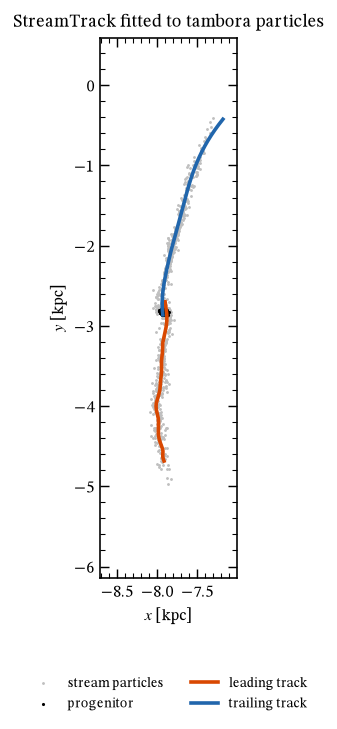

In [8]:
COL = {"leading": "#d94801", "trailing": "#2166ac"}

fig, ax = plt.subplots(figsize=(6.0, 5.4))
ax.scatter(p_now[unbound, 0], p_now[unbound, 1], s=2.5, lw=0, c="0.75",
           label="stream particles", rasterized=True)
ax.scatter(p_now[bound, 0], p_now[bound, 1], s=3, lw=0, c="k", label="progenitor")
for name, (trk, te) in tracks.items():
    ax.plot(trk.x(te), trk.y(te), lw=2.0, c=COL[name], label=f"{name} track")
xs, ys = p_now[unbound, 0], p_now[unbound, 1]
xw, yw = np.ptp(xs) * 1.15, np.ptp(ys) * 1.06
ax.set_xlim(xs.mean() - xw / 2, xs.mean() + xw / 2)
ax.set_ylim(ys.mean() - yw / 2, ys.mean() + yw / 2)
ax.set_box_aspect(yw / xw)
ax.set_xlabel("$x$ [kpc]")
ax.set_ylabel("$y$ [kpc]")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=7.5)
ax.set_title("StreamTrack fitted to tambora particles")
plt.show()

## 5. Observables

This is the payoff. The fitted track exposes every heliocentric observable
directly — no manual coordinate transforms, and the solar position and motion
are handled internally.

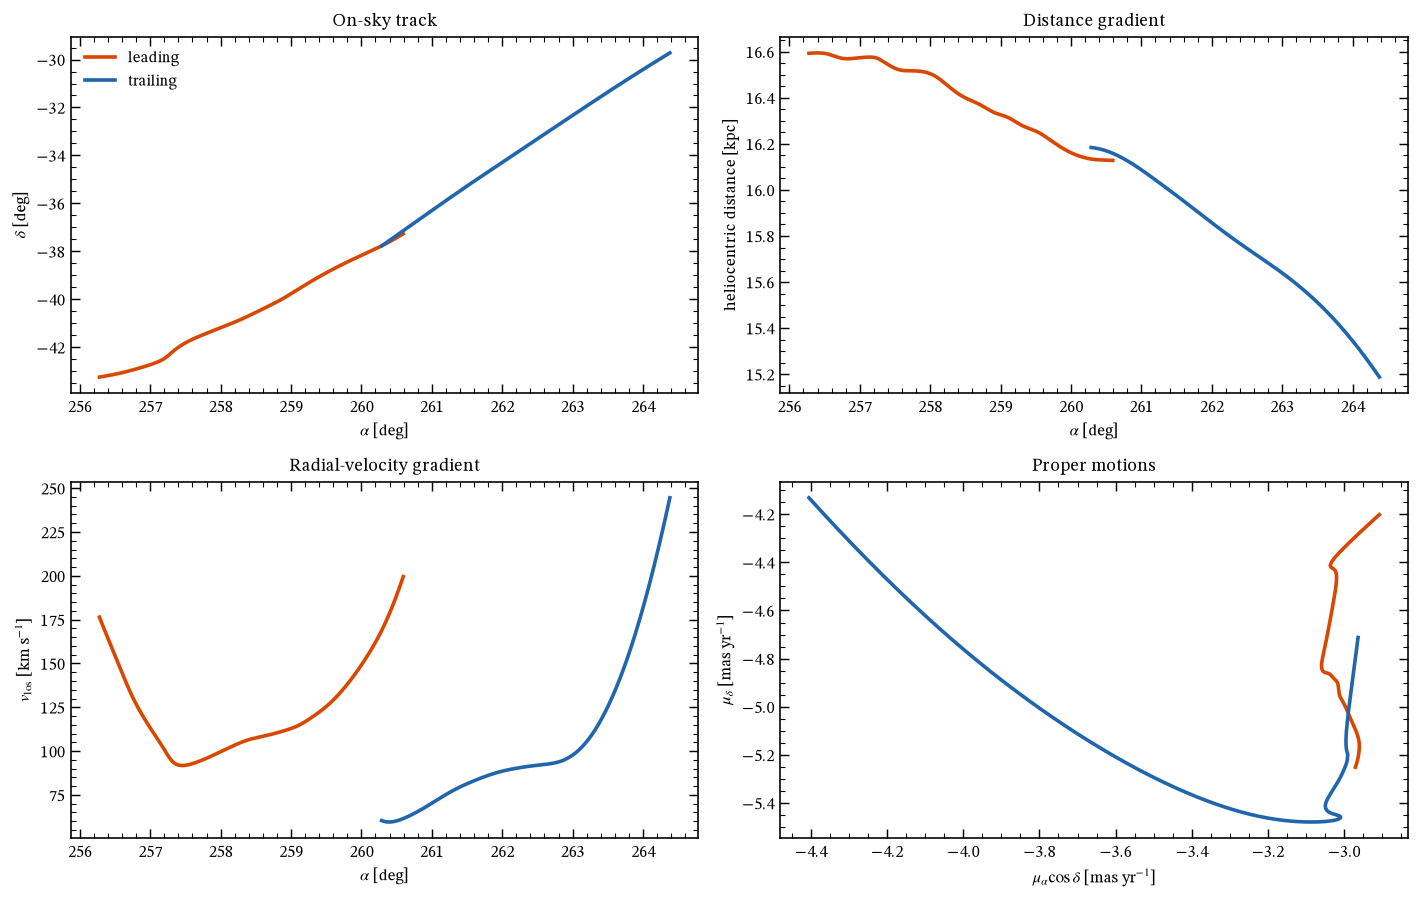

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(11.0, 7.0))

for name, (trk, te) in tracks.items():
    c = COL[name]
    ax[0, 0].plot(trk.ra(te), trk.dec(te), lw=2, c=c, label=name)
    ax[0, 1].plot(trk.ra(te), trk.dist(te), lw=2, c=c)
    ax[1, 0].plot(trk.ra(te), trk.vlos(te), lw=2, c=c)
    ax[1, 1].plot(trk.pmra(te), trk.pmdec(te), lw=2, c=c)

ax[0, 0].set_xlabel(r"$\alpha$ [deg]")
ax[0, 0].set_ylabel(r"$\delta$ [deg]")
ax[0, 0].set_title("On-sky track")
ax[0, 0].legend()

ax[0, 1].set_xlabel(r"$\alpha$ [deg]")
ax[0, 1].set_ylabel("heliocentric distance [kpc]")
ax[0, 1].set_title("Distance gradient")

ax[1, 0].set_xlabel(r"$\alpha$ [deg]")
ax[1, 0].set_ylabel(r"$v_{\rm los}$ [km s$^{-1}$]")
ax[1, 0].set_title("Radial-velocity gradient")

ax[1, 1].set_xlabel(r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]")
ax[1, 1].set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax[1, 1].set_title("Proper motions")

fig.tight_layout()
plt.show()

The distance and velocity gradients along the track are the quantities that make
a stream a useful potential probe: they are set by the host's mass distribution
along the orbit, and they are what a spectroscopic survey measures.

There is also a `phi1`/`phi2` pair for a great-circle frame aligned with the
stream, if you pass a `custom_sky_transform` rotation matrix — the convention
most published stream papers use.

## 6. Stream width

Fitting with `order=2` stores the full $6\times6$ covariance of the particle
distribution as a function of position along the track. `cov(tp, basis=...)`
returns it in whichever coordinate system you want, transformed by analytic
Jacobians. The positional part gives the width.

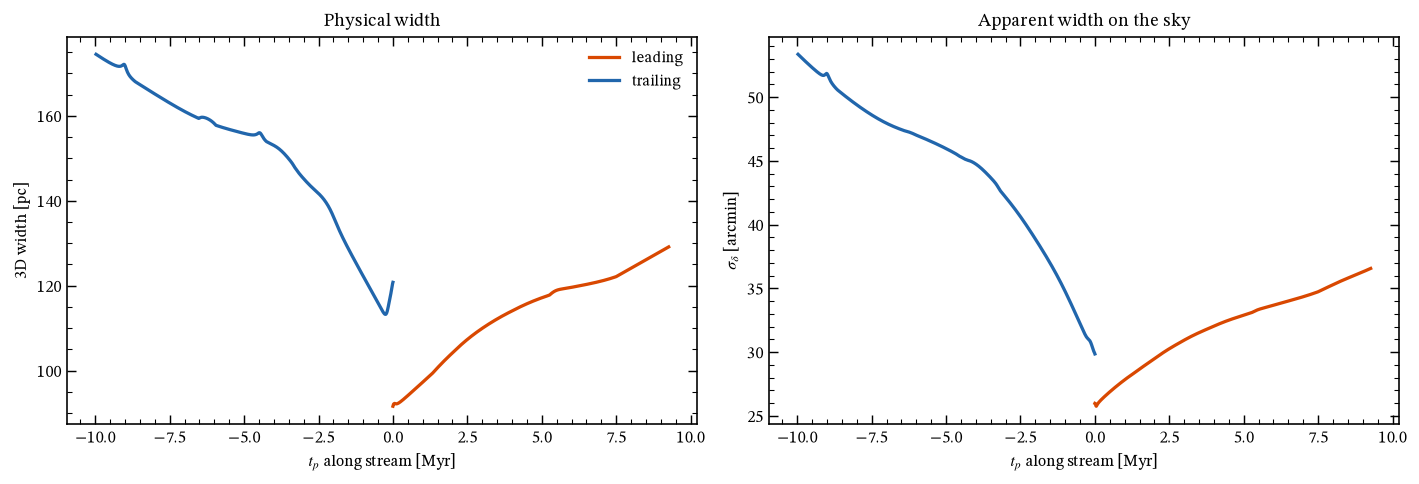

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.8))

for name, (trk, te) in tracks.items():
    C = np.array([trk.cov(t, basis="galcenrect") for t in te])
    var_pos = np.diagonal(C, axis1=1, axis2=2)[:, :3]
    width = np.sqrt(np.maximum(var_pos.sum(1) / 3, 0))  # mean 3D width
    ax[0].plot(te * TU * 1000, width * 1000, lw=1.8, c=COL[name], label=name)

    C_sky = np.array([trk.cov(t, basis="sky") for t in te])
    ang = np.sqrt(np.maximum(np.diagonal(C_sky, axis1=1, axis2=2)[:, 1], 0))
    ax[1].plot(te * TU * 1000, ang * 60, lw=1.8, c=COL[name], label=name)

ax[0].set_xlabel(r"$t_p$ along stream [Myr]")
ax[0].set_ylabel("3D width [pc]")
ax[0].set_title("Physical width")
ax[0].legend()

ax[1].set_xlabel(r"$t_p$ along stream [Myr]")
ax[1].set_ylabel(r"$\sigma_\delta$ [arcmin]")
ax[1].set_title("Apparent width on the sky")
fig.tight_layout()
plt.show()

The width is **smallest at the progenitor and grows outward along both tails**.
That is the expected signature: stars released earlier have had longer to
disperse in the directions transverse to the orbit, so the tails fan slowly with
distance from the remnant.

## 7. Length and linear density

The track parameter $t_p$ is a natural coordinate along the stream — it is the
progenitor's orbital time — so binning particles in it gives the linear density
without needing to define an arbitrary arc-length axis.

leading   arc length 2.04 kpc over 9.3 Myr
trailing  arc length 2.63 kpc over 10.0 Myr


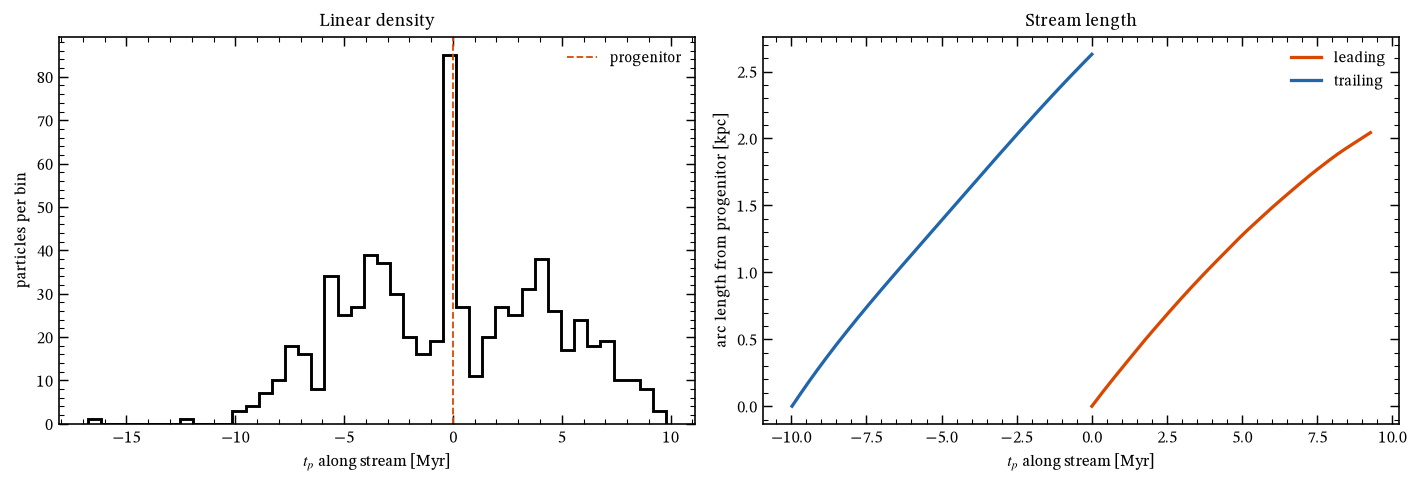

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.8))

bins = np.linspace(tp.min(), tp.max(), 45)
ax[0].hist(tp * 1000, bins=bins * 1000, color="k", histtype="step", lw=1.6)
ax[0].axvline(0, c="#d94801", lw=1.0, ls="--", label="progenitor")
ax[0].set_xlabel(r"$t_p$ along stream [Myr]")
ax[0].set_ylabel("particles per bin")
ax[0].set_title("Linear density")
ax[0].legend()

# convert tp to physical arc length along the fitted track
for name, (trk, te) in tracks.items():
    xyz = np.array([trk.x(te), trk.y(te), trk.z(te)]).T
    s = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(xyz, axis=0), axis=1))])
    ax[1].plot(te * TU * 1000, s, lw=1.8, c=COL[name], label=name)
    print(f"{name:9s} arc length {s[-1]:.2f} kpc over {np.ptp(te) * TU * 1000:.1f} Myr")

ax[1].set_xlabel(r"$t_p$ along stream [Myr]")
ax[1].set_ylabel("arc length from progenitor [kpc]")
ax[1].set_title("Stream length")
ax[1].legend()
fig.tight_layout()
plt.show()

## Summary: the tambora ↔ galpy handshake

The whole bridge is four steps, and none of them needs either package to know
about the other:

1. `tambora_to_galpy_xv(sim.gc.pos(t=-1), sim.gc.vel(t=-1))` — a coordinate
   transform and a division by `ro`/`vo`.
2. Build the progenitor `Orbit` from the bound centre of mass
   (`BoundednessHook` gives you this for free).
3. Integrate it forwards **and** backwards to get a dense reference curve.
4. `StreamTrack.from_particles(...)` once per arm.

After that, everything galpy knows about coordinates, solar motion and
covariance propagation is available to a simulation tambora ran.

## Where to go next

- [Subhalo impacts and stream gaps](07-stream-gaps.ipynb) — perturb this stream
  and look for the signature in exactly these observables.
- [Tidal stripping](05-tidal-stripping.ipynb) — where the debris came from.
- [Interoperability](../guide/interoperability.md) — the other galpy touchpoints.

Things to try:

- Fit at several epochs and watch the width and length grow.
- Pass a `custom_sky_transform` to get $\phi_1$/$\phi_2$ in a great-circle frame.
- Re-fit with `order=1` (mean only) and time it — the covariance is most of the
  cost.